In [ ]:
# --- setup ---
import sys, os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

try:
    import pgsca
except ImportError:
    sys.path.insert(0, os.path.abspath('..'))
    import pgsca

from pgsca import (make_gaussian_fields, make_lithotype_map,
                   build_table, sequential_simulate, compute_morphology,
                   estimate_anisotropy, recover_plurigaussian, make_pgs_seed)



pgsca version 0.1.0


In [2]:
# a field with KNOWN parameters (pretend we don't know them)
grid_size = 110
true_alpha_deg = 60.0
true_L_major, true_L_minor = 30, 10

f_true, _ = make_gaussian_fields(grid_size=grid_size,
                                 len_scale_1=[true_L_major, true_L_minor],
                                 angles_1=[np.deg2rad(true_alpha_deg), 0], seed_1=1)
B = (f_true > 0).astype(int)   # the indicator we get to see

(alpha, L_major, L_minor,
 coarse_angles, coarse_ranges, fine_angles, fine_ranges) = estimate_anisotropy(
     B, coarse_sampling_size=1500, fine_sampling_size=2000, final_sampling_size=2500)

print(f"true      : angle {true_alpha_deg:.1f} deg | L_major {true_L_major} | L_minor {true_L_minor}")
print(f"recovered : angle {np.rad2deg(alpha) % 180:.1f} deg | "
      f"L_major {L_major:.1f} | L_minor {L_minor:.1f}")


true      : angle 60.0 deg | L_major 30 | L_minor 10
recovered : angle 66.0 deg | L_major 34.4 | L_minor 8.9


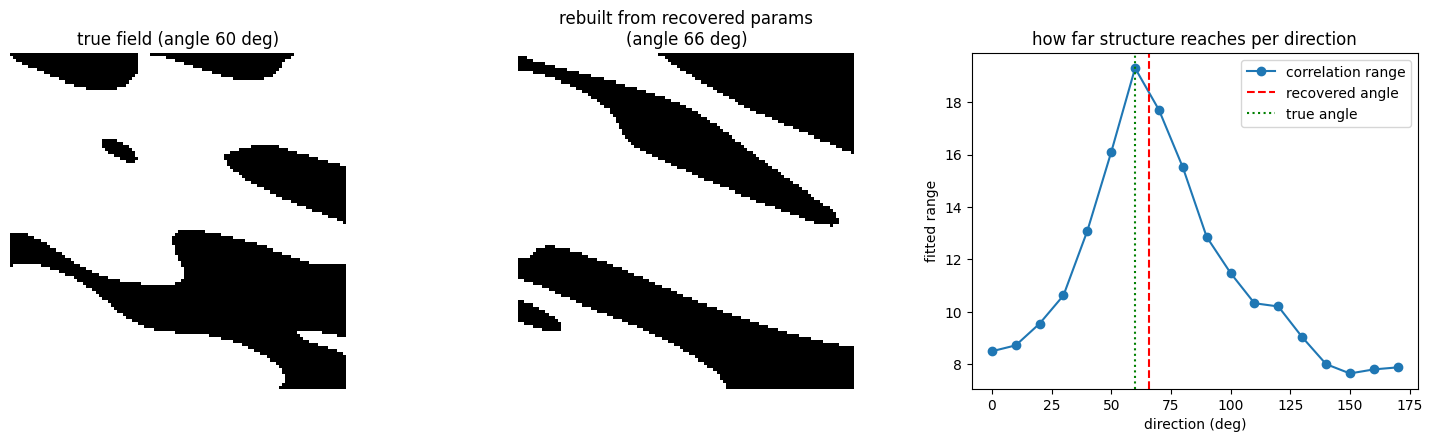

In [3]:
# rebuild a field from the RECOVERED params and eyeball it against the real one
f_est, _ = make_gaussian_fields(grid_size=grid_size,
                                len_scale_1=[L_major, L_minor],
                                angles_1=[alpha, 0], seed_1=99)  # different seed on purpose
B_est = (f_est > 0).astype(int)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
ax[0].imshow(B, cmap='gray'); ax[0].set_title(f'true field (angle {true_alpha_deg:.0f} deg)'); ax[0].axis('off')
ax[1].imshow(B_est, cmap='gray'); ax[1].set_title(f'rebuilt from recovered params\n(angle {np.rad2deg(alpha)%180:.0f} deg)'); ax[1].axis('off')
ax[2].plot(np.rad2deg(coarse_angles), coarse_ranges, 'o-', label='correlation range')
ax[2].axvline(np.rad2deg(alpha) % 180, color='r', ls='--', label='recovered angle')
ax[2].axvline(true_alpha_deg, color='g', ls=':', label='true angle')
ax[2].set_xlabel('direction (deg)'); ax[2].set_ylabel('fitted range')
ax[2].set_title('how far structure reaches per direction'); ax[2].legend()
plt.tight_layout(); plt.show()


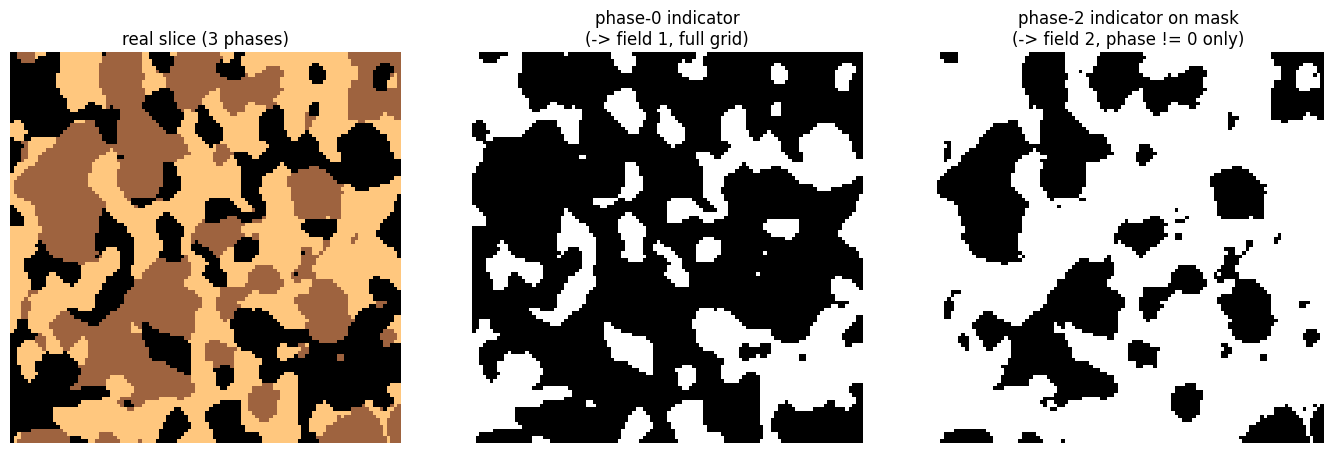

In [4]:
import tifffile

cands = ['../data/ThreePhase.tif', 'data/ThreePhase.tif',
         os.path.join(os.path.dirname(pgsca.__file__), '..', 'data', 'ThreePhase.tif')]
tif_path = next((p for p in cands if os.path.exists(p)), cands[0])

lut = np.zeros(256, int); lut[0], lut[128], lut[255] = 0, 1, 2   # 0/128/255 -> 0/1/2
vol = lut[tifffile.imread(tif_path)]

N = 110
real = vol[128][:N, :N]

# the two indicators the cascade actually works on
B0   = (real == 0)                 # field 1 lives here (full grid)
mask = real != 0                   # field 2 only expressed here
I2   = np.where(mask, real == 2, np.nan)   # phase-2 indicator, masked

fig, ax = plt.subplots(1, 3, figsize=(14, 4.5))
ax[0].imshow(real, cmap='copper', vmin=0, vmax=2); ax[0].set_title('real slice (3 phases)'); ax[0].axis('off')
ax[1].imshow(B0, cmap='gray'); ax[1].set_title('phase-0 indicator\n(-> field 1, full grid)'); ax[1].axis('off')
ax[2].imshow(I2, cmap='gray'); ax[2].set_title('phase-2 indicator on mask\n(-> field 2, phase != 0 only)'); ax[2].axis('off')
plt.tight_layout(); plt.show()


In [5]:
rec = recover_plurigaussian(real, coarse_sampling_size=1000,
                            fine_sampling_size=1200, final_sampling_size=1500)

print("recovered proportions :", [float(round(p, 3)) for p in rec['proportions']])
print("threshold cut 1       :", round(rec['cut_1'], 3))
print("threshold cut 2       :", round(rec['cut_2'], 3))
print("field 1 (angle deg, L_major, L_minor):",
      [float(round(x, 1)) for x in (np.rad2deg(rec['params_1'][0]), rec['params_1'][1], rec['params_1'][2])])
print("field 2 (angle deg, L_major, L_minor):",
      [float(round(x, 1)) for x in (np.rad2deg(rec['params_2'][0]), rec['params_2'][1], rec['params_2'][2])])


recovered proportions : [0.312, 0.314, 0.374]
threshold cut 1       : -0.491
threshold cut 2       : -0.109
field 1 (angle deg, L_major, L_minor): [20.0, 7.1, 5.4]
field 2 (angle deg, L_major, L_minor): [170.0, 10.8, 6.4]


Stopped (no further improvement) after 2 pass(es)  (improvement = -0.0039 < 0.005)


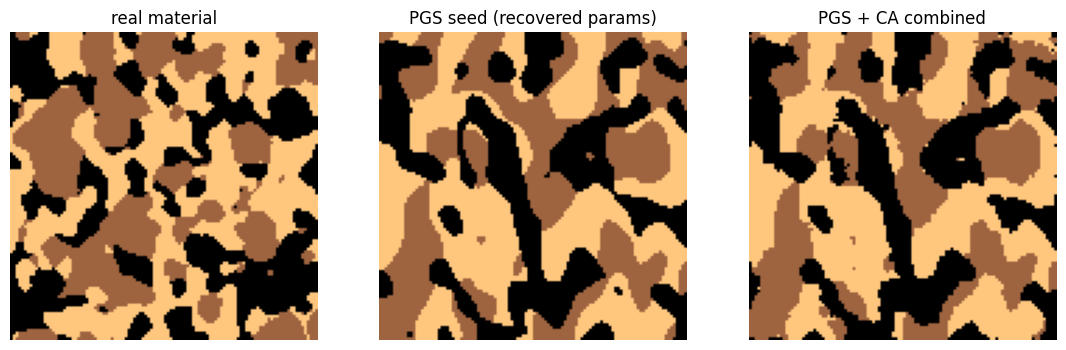

In [6]:
def show_maps(maps, titles):
    fig, axes = plt.subplots(1, len(maps), figsize=(4.5*len(maps), 4.5))
    for ax, m, t in zip(axes, maps, titles):
        ax.imshow(m, cmap='copper', vmin=0, vmax=2); ax.set_title(t); ax.axis('off')
    plt.show()

# regenerate a fresh seed from the recovered parameters (new random seeds)
seed = make_pgs_seed((N, N), rec['params_1'], rec['params_2'], rec['proportions'],
                     seed_1=11, seed_2=12)

# learn a Moore K-map from a few spread-out real slices, then refine the seed
train = [vol[k][:N, :N] for k in range(0, 256, 26)][:10]
table = build_table([(s, s) for s in train], neighbourhood='moore')
combined, _ = sequential_simulate(table, (N, N), proportions=rec['proportions'],
                                  initial_grid=seed, n_passes=8,
                                  rng=np.random.default_rng(1))

show_maps([real, seed, combined], ['real material', 'PGS seed (recovered params)', 'PGS + CA combined'])


In [7]:
import pandas as pd
rows = []
for name, m in [('real', real), ('PGS seed', seed), ('combined', combined)]:
    d = compute_morphology(m)[0]   # phase 0
    rows.append({'source': name,
                 'proportion': round(d['proportion'], 3),
                 'n_components': d['n_components'],
                 'mean_area': round(d['mean_area'], 1),
                 'largest_area': d['largest_area'],
                 'percolates': d['percolates']})
display(pd.DataFrame(rows).set_index('source'))


,proportion,n_components,mean_area,largest_area,percolates
source,,,,,
real,0.312,33,114.2,939,False
PGS seed,0.312,18,209.4,1428,False
combined,0.311,32,117.7,1378,False


In [8]:
def pattern_ids(grid, neighbourhood):
    '''base-3 encode every cell's neighbourhood, same scheme as build_table.'''
    rows, cols = grid.shape
    p = np.pad(grid, 1, constant_values=0)
    n = p[0:rows, 1:cols+1]; s = p[2:rows+2, 1:cols+1]
    e = p[1:rows+1, 2:cols+2]; w = p[1:rows+1, 0:cols]
    if neighbourhood == 'moore':
        ne = p[0:rows, 2:cols+2]; nw = p[0:rows, 0:cols]
        se = p[2:rows+2, 2:cols+2]; sw = p[2:rows+2, 0:cols]
        return (n*2187 + s*729 + e*243 + w*81 + ne*27 + nw*9 + se*3 + sw).ravel()
    return (n*27 + s*9 + e*3 + w).ravel()

one_slice  = [(real, real)]
ten_slices = [(vol[k][:N, :N], vol[k][:N, :N]) for k in range(0, 256, 26)][:10]

for nb in ['von_neumann', 'moore']:
    t1  = build_table(one_slice,  neighbourhood=nb)
    t10 = build_table(ten_slices, neighbourhood=nb)
    freq = np.bincount(pattern_ids(real, nb), minlength=t1.shape[0]).astype(float)
    freq /= freq.sum()
    seen = freq > 0
    tv = 0.5 * np.abs(t1 - t10).sum(axis=1)                 # per-pattern difference
    wtv = (freq[seen] * tv[seen]).sum()                     # frequency-weighted
    same = (freq[seen] * (t1[seen].argmax(1) == t10[seen].argmax(1))).sum()
    print(f"{nb:12s}: patterns actually seen = {seen.sum():5d}/{t1.shape[0]:5d} | "
          f"table difference (1 vs 10 slices) = {wtv:.4f} | same top choice = {same:.1%}")


von_neumann : patterns actually seen =    74/   81 | table difference (1 vs 10 slices) = 0.0080 | same top choice = 95.6%
moore       : patterns actually seen =   579/ 6561 | table difference (1 vs 10 slices) = 0.0235 | same top choice = 97.1%


Stopped (no further improvement) after 2 pass(es)  (improvement = -0.0103 < 0.005)
Stopped (no further improvement) after 2 pass(es)  (improvement = -0.0039 < 0.005)


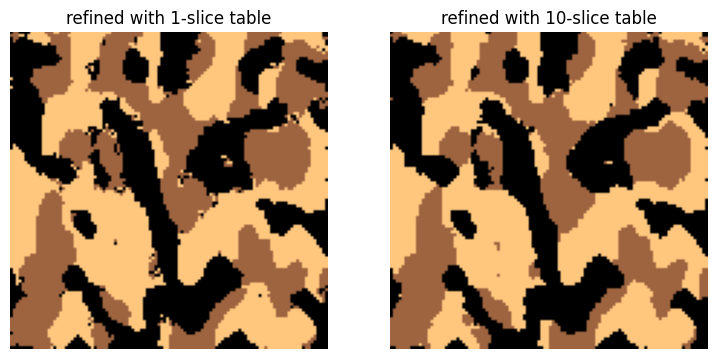

,proportion,n_components,mean_area
table,,,
1-slice table,0.313,66,57.4
10-slice table,0.311,32,117.7


pixels that differ between the two refined maps: 5.3%


In [9]:
# downstream: refine the SAME seed with the 1-slice and 10-slice Moore tables
t1_m  = build_table(one_slice,  neighbourhood='moore')
t10_m = build_table(ten_slices, neighbourhood='moore')
ref1,  _ = sequential_simulate(t1_m,  (N, N), proportions=rec['proportions'],
                               initial_grid=seed, n_passes=8, rng=np.random.default_rng(1))
ref10, _ = sequential_simulate(t10_m, (N, N), proportions=rec['proportions'],
                               initial_grid=seed, n_passes=8, rng=np.random.default_rng(1))

show_maps([ref1, ref10], ['refined with 1-slice table', 'refined with 10-slice table'])

rows = []
for name, m in [('1-slice table', ref1), ('10-slice table', ref10)]:
    d = compute_morphology(m)[0]
    rows.append({'table': name, 'proportion': round(d['proportion'], 3),
                 'n_components': d['n_components'], 'mean_area': round(d['mean_area'], 1)})
display(pd.DataFrame(rows).set_index('table'))
print(f"pixels that differ between the two refined maps: {np.mean(ref1 != ref10):.1%}")
